# Residual Connections: The Key to Training Deep Networks

**Residual connections** (also called **skip connections**) revolutionized deep learning by enabling networks with hundreds of layers where previously we could barely train dozens. They're the core innovation behind ResNet (2015), which won ImageNet and sparked the deep learning revolution, and are essential in modern Transformers.

## What We'll Learn

1. **The vanishing gradient problem** - why deep networks fail to train
2. **Skip connections** - the elegant solution that changes everything
3. **Residual blocks** - how to implement them from scratch
4. **Why they work** - gradient highways and ensemble interpretation
5. **Experiments** - comparing plain vs residual networks

## Why This Matters

Before residual connections, training networks deeper than ~20 layers was extremely difficult. Counterintuitively, adding more layers often made networks **worse**, not better. ResNets solved this, enabling networks with 50, 101, or even 1000+ layers.

**Key applications:**
- **ResNet**: State-of-the-art image classification (152 layers)
- **Transformers**: Residual connections around attention and feedforward layers
- **U-Net**: Skip connections between encoder and decoder for image segmentation
- **GANs**: Stabilizing training in deep generators and discriminators

## Setup

We'll import PyTorch for building networks and matplotlib for visualizations.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Import shared utilities
from aiml_notebooks import get_device, set_seed

# Enable autoreload for hot reloading
%load_ext autoreload
%autoreload 2

print(f"PyTorch: {torch.__version__}")

PyTorch: 2.9.0+cu128


Set the random seed for reproducibility and configure the device (GPU if available).

In [2]:
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Using CPU
Using device: cpu


## 1. The Vanishing Gradient Problem

### The Intuition

When training deep networks, gradients must flow backward through many layers during backpropagation. At each layer, gradients get multiplied by the layer's weights and activation derivatives.

If these multiplications are typically less than 1 (common with sigmoid/tanh activations or small weight initializations), gradients **shrink exponentially** as they flow backward. By the time they reach early layers, they're essentially zero - the network can't learn.

$$\text{gradient}_{\text{layer } 1} = \text{gradient}_{\text{output}} \times \underbrace{W_n \times W_{n-1} \times \cdots \times W_2}_{\text{many multiplications < 1}}$$

This is the **vanishing gradient problem**. Let's demonstrate it.

### Building a Plain Deep Network

We'll create a simple deep network with many layers to observe gradient flow.

In [3]:
class PlainDeepNetwork(nn.Module):
    """A plain deep network without skip connections."""
    
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.layers = nn.ModuleList()
        
        # Input layer
        self.layers.append(nn.Linear(input_size, hidden_size))
        
        # Hidden layers
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(hidden_size, hidden_size))
        
        # Output layer
        self.layers.append(nn.Linear(hidden_size, output_size))
        
    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = F.relu(layer(x))
        x = self.layers[-1](x)  # No activation on output
        return x

# Create a 20-layer plain network
plain_net = PlainDeepNetwork(input_size=64, hidden_size=64, num_layers=20, output_size=10)
plain_net = plain_net.to(device)
print(f"Plain network layers: {len(plain_net.layers)}")
print(f"Parameters: {sum(p.numel() for p in plain_net.parameters()):,}")

Plain network layers: 20
Parameters: 79,690


### Measuring Gradient Flow

Let's perform a forward and backward pass, then measure the gradient magnitudes at each layer. If gradients are vanishing, early layers will have much smaller gradients than later layers.

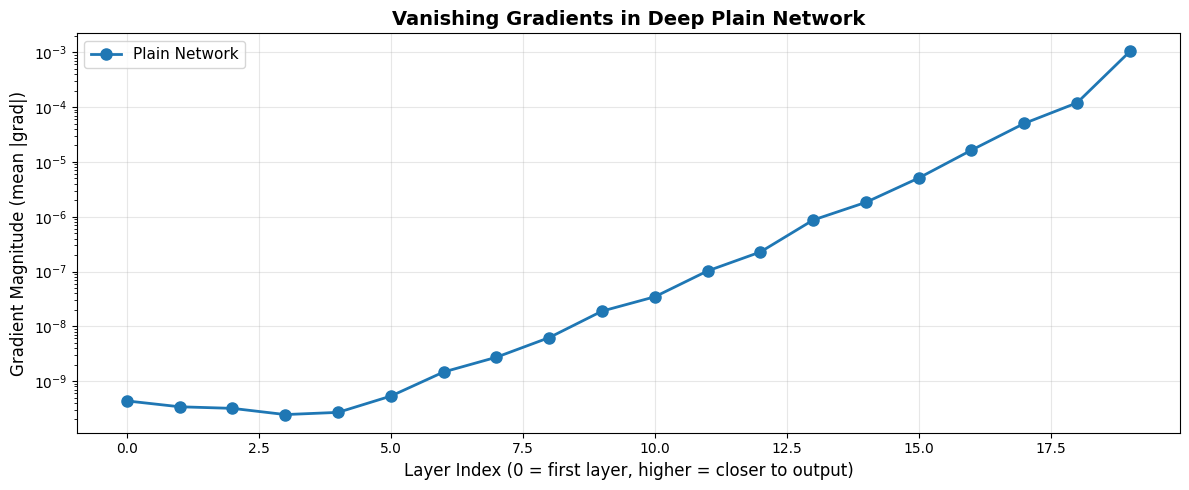

First layer gradient: 4.36e-10
Last layer gradient: 1.04e-03
Ratio (first/last): 4.21e-07


In [4]:
def measure_gradient_flow(model, input_size, device):
    """Measure gradient magnitudes at each layer."""
    model.zero_grad()
    
    # Forward pass with random input
    x = torch.randn(32, input_size, device=device)
    output = model(x)
    
    # Backward pass with random target
    target = torch.randint(0, 10, (32,), device=device)
    loss = F.cross_entropy(output, target)
    loss.backward()
    
    # Collect gradient magnitudes (mean absolute value)
    grad_magnitudes = []
    for layer in model.layers:
        if hasattr(layer, 'weight') and layer.weight.grad is not None:
            grad_mag = layer.weight.grad.abs().mean().item()
            grad_magnitudes.append(grad_mag)
    
    return grad_magnitudes

# Measure gradients in plain network
plain_grads = measure_gradient_flow(plain_net, input_size=64, device=device)

# Plot gradient magnitudes
plt.figure(figsize=(12, 5))
plt.plot(range(len(plain_grads)), plain_grads, 'o-', linewidth=2, markersize=8, label='Plain Network')
plt.xlabel('Layer Index (0 = first layer, higher = closer to output)', fontsize=12)
plt.ylabel('Gradient Magnitude (mean |grad|)', fontsize=12)
plt.title('Vanishing Gradients in Deep Plain Network', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale to see the exponential decay
plt.tight_layout()
plt.show()

print(f"First layer gradient: {plain_grads[0]:.2e}")
print(f"Last layer gradient: {plain_grads[-1]:.2e}")
print(f"Ratio (first/last): {plain_grads[0]/plain_grads[-1]:.2e}")

### Key Observation

Notice how gradients in early layers are **orders of magnitude smaller** than in later layers. The first layer might have gradients ~1000x smaller than the last layer.

This means:
- **Early layers barely learn** - their parameters hardly change
- **Later layers dominate training** - they update much faster
- **Deep networks fail** - adding more layers makes the problem worse

This is why, before ResNets, deeper networks often performed **worse** than shallower ones - not due to overfitting, but because they couldn't train properly.

## 2. Skip Connections: The Elegant Solution

### The Core Idea

Instead of learning a direct mapping $H(x)$, learn the **residual** $F(x) = H(x) - x$, then add the input back:

$$H(x) = F(x) + x$$

Where:
- $x$ is the input (the **skip connection**)
- $F(x)$ is what the layer learns (the **residual**)
- $H(x)$ is the output

**Why this helps:**
1. **Easy identity mapping**: If optimal is to pass input unchanged, the layer can learn $F(x) = 0$ (easier than learning $H(x) = x$ from scratch)
2. **Gradient highways**: Gradients can flow directly through the skip connection, bypassing layers
3. **Implicit ensemble**: Network acts like an ensemble of shallower networks

This simple addition **revolutionized** deep learning.

### Visual Comparison

Let's visualize the difference between plain and residual blocks:

**Plain Block:**
```
x → [Linear → ReLU → Linear → ReLU] → output
```

**Residual Block:**
```
     ┌─────────────────────────┐
     │                         │
x ───┤→ [Linear → ReLU → Linear] ─→ (+) → ReLU → output
     │                              ↑
     └──────────────────────────────┘
          (skip connection)
```

The skip connection creates an alternative path for gradients to flow backward.

## 3. Implementing Residual Blocks

### Basic Residual Block

Let's implement a residual block from scratch following the ResNet design.

In [5]:
class ResidualBlock(nn.Module):
    """A residual block with skip connection.
    
    Implements: output = ReLU(F(x) + x)
    where F(x) = Linear(ReLU(Linear(x)))
    """
    
    def __init__(self, hidden_size):
        super().__init__()
        # Two linear layers with batch norm
        self.linear1 = nn.Linear(hidden_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        
    def forward(self, x):
        # Save input for skip connection
        identity = x
        
        # Residual path (learning F(x))
        out = self.linear1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.linear2(out)
        out = self.bn2(out)
        
        # Add skip connection: H(x) = F(x) + x
        out = out + identity
        
        # Final activation
        out = F.relu(out)
        
        return out

# Test the residual block
block = ResidualBlock(hidden_size=64).to(device)
x = torch.randn(32, 64, device=device)
output = block(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Parameters: {sum(p.numel() for p in block.parameters()):,}")

Input shape: torch.Size([32, 64])
Output shape: torch.Size([32, 64])
Parameters: 8,576


### Building a Residual Network (ResNet)

Now we'll stack multiple residual blocks to create a deep residual network.

In [6]:
class ResNet(nn.Module):
    """A deep residual network with skip connections."""
    
    def __init__(self, input_size, hidden_size, num_blocks, output_size):
        super().__init__()
        
        # Input projection
        self.input_layer = nn.Linear(input_size, hidden_size)
        
        # Stack of residual blocks
        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_size) for _ in range(num_blocks)
        ])
        
        # Output layer
        self.output_layer = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # Project to hidden dimension
        x = F.relu(self.input_layer(x))
        
        # Pass through residual blocks
        for block in self.blocks:
            x = block(x)
        
        # Output projection
        x = self.output_layer(x)
        return x

# Create a 20-layer ResNet (10 residual blocks × 2 layers each)
resnet = ResNet(input_size=64, hidden_size=64, num_blocks=10, output_size=10)
resnet = resnet.to(device)
print(f"ResNet blocks: {len(resnet.blocks)}")
print(f"Total layers: ~{len(resnet.blocks) * 2} (2 layers per block)")
print(f"Parameters: {sum(p.numel() for p in resnet.parameters()):,}")

ResNet blocks: 10
Total layers: ~20 (2 layers per block)
Parameters: 90,570


### Comparing Gradient Flow

Let's measure gradients in our ResNet and compare them to the plain network.

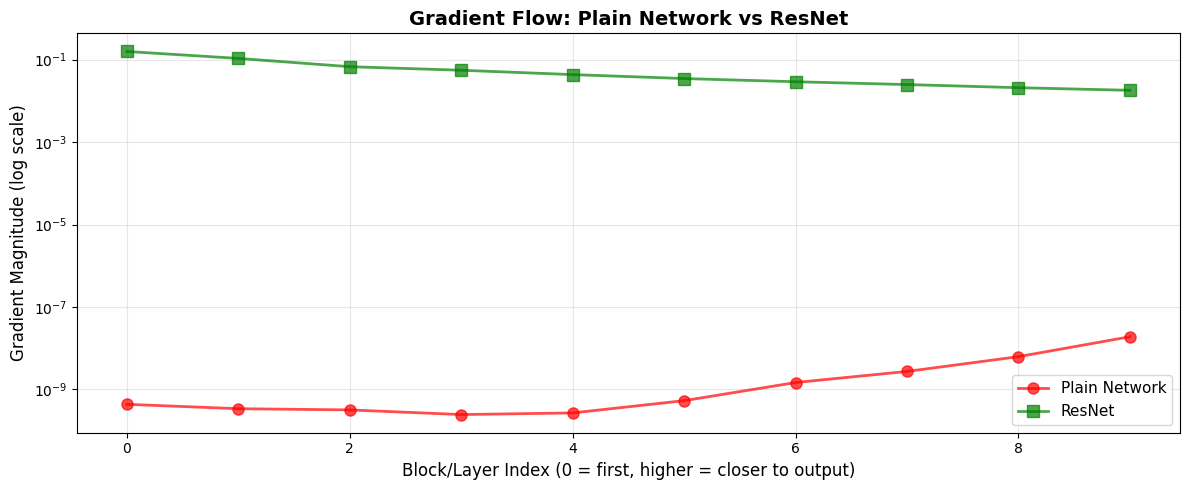


Plain Network:
  First layer gradient: 4.36e-10
  Last layer gradient: 1.89e-08
  Ratio: 2.30e-02

ResNet:
  First block gradient: 1.57e-01
  Last block gradient: 1.80e-02
  Ratio: 8.75e+00


In [7]:
def measure_gradient_flow_resnet(model, input_size, device):
    """Measure gradient magnitudes in ResNet."""
    model.zero_grad()
    
    # Forward pass
    x = torch.randn(32, input_size, device=device)
    output = model(x)
    
    # Backward pass
    target = torch.randint(0, 10, (32,), device=device)
    loss = F.cross_entropy(output, target)
    loss.backward()
    
    # Collect gradients from residual blocks
    grad_magnitudes = []
    for block in model.blocks:
        grad_mag = block.linear1.weight.grad.abs().mean().item()
        grad_magnitudes.append(grad_mag)
    
    return grad_magnitudes

# Measure gradients
resnet_grads = measure_gradient_flow_resnet(resnet, input_size=64, device=device)

# Plot comparison
plt.figure(figsize=(12, 5))
plt.plot(range(len(plain_grads[:10])), plain_grads[:10], 'o-', linewidth=2, markersize=8, 
         label='Plain Network', color='red', alpha=0.7)
plt.plot(range(len(resnet_grads)), resnet_grads, 's-', linewidth=2, markersize=8, 
         label='ResNet', color='green', alpha=0.7)
plt.xlabel('Block/Layer Index (0 = first, higher = closer to output)', fontsize=12)
plt.ylabel('Gradient Magnitude (log scale)', fontsize=12)
plt.title('Gradient Flow: Plain Network vs ResNet', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"\nPlain Network:")
print(f"  First layer gradient: {plain_grads[0]:.2e}")
print(f"  Last layer gradient: {plain_grads[9]:.2e}")
print(f"  Ratio: {plain_grads[0]/plain_grads[9]:.2e}")

print(f"\nResNet:")
print(f"  First block gradient: {resnet_grads[0]:.2e}")
print(f"  Last block gradient: {resnet_grads[-1]:.2e}")
print(f"  Ratio: {resnet_grads[0]/resnet_grads[-1]:.2e}")

### Key Insight: Gradient Highways

Notice how ResNet maintains much more **uniform gradient magnitudes** across layers compared to the plain network. The gradients don't vanish!

**Why?** During backpropagation, the gradient can flow through two paths:

1. **Through the residual function** $F(x)$ (standard backprop)
2. **Through the skip connection** (direct path, no multiplication)

The skip connection acts as a **gradient highway** - even if gradients through $F(x)$ vanish, gradients can still flow directly through the skip connection:

$$\frac{\partial}{\partial x}(F(x) + x) = \frac{\partial F(x)}{\partial x} + 1$$

The $+1$ term ensures gradients never completely vanish!

## 4. Why Residual Connections Work

### Interpretation 1: Easier Optimization

Learning the residual $F(x) = H(x) - x$ is easier than learning $H(x)$ directly when the optimal transformation is close to identity.

**Example:** If the optimal mapping is $H(x) = x$ (identity), then:
- **Plain network**: Must learn $H(x) = x$ from random initialization (hard)
- **ResNet**: Only needs to learn $F(x) = 0$ (much easier - weights just need to shrink toward zero)

Let's demonstrate this.

Training plain network to learn identity...


Training ResNet to learn identity...


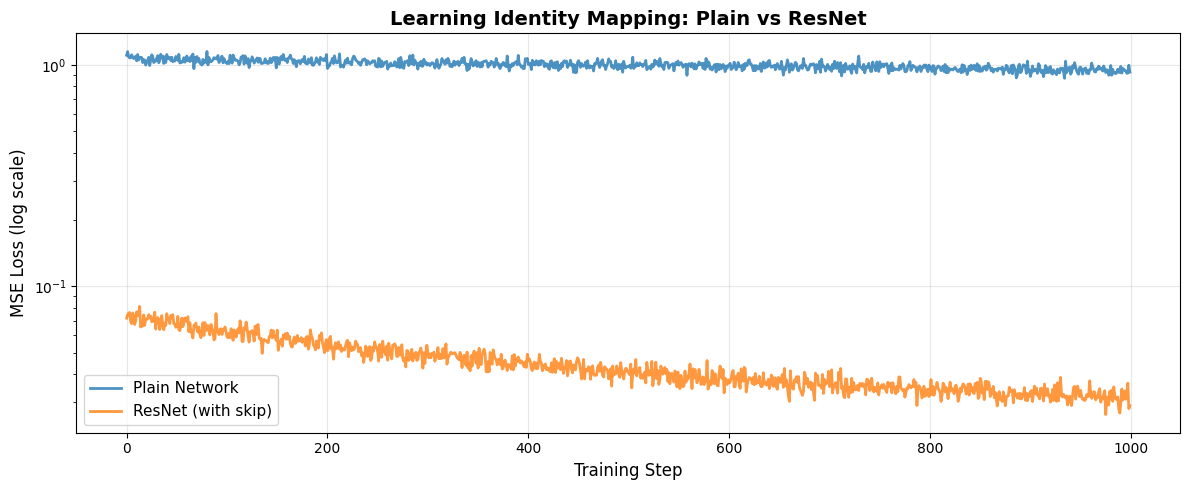


Final loss (Plain): 0.926429
Final loss (ResNet): 0.028930
ResNet learns 32.0x better!


In [8]:
# Create simple task: learn identity mapping
def train_identity_mapping(model, num_steps=1000, lr=0.01):
    """Train a model to learn the identity mapping."""
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    
    for step in range(num_steps):
        # Generate random input
        x = torch.randn(32, 64, device=device)
        
        # Forward pass
        output = model(x)
        
        # Loss: how close is output to input (identity)?
        loss = F.mse_loss(output, x)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    return losses

# Simple network that must learn identity
class SimpleNet(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.linear1 = nn.Linear(size, size)
        self.linear2 = nn.Linear(size, size)
    
    def forward(self, x):
        return self.linear2(F.relu(self.linear1(x)))

# Network with skip connection
class SimpleResNet(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.linear1 = nn.Linear(size, size)
        self.linear2 = nn.Linear(size, size)
    
    def forward(self, x):
        identity = x
        out = self.linear2(F.relu(self.linear1(x)))
        return out + identity  # Skip connection

# Train both
print("Training plain network to learn identity...")
plain_simple = SimpleNet(64).to(device)
plain_losses = train_identity_mapping(plain_simple, num_steps=1000, lr=0.01)

print("Training ResNet to learn identity...")
res_simple = SimpleResNet(64).to(device)
res_losses = train_identity_mapping(res_simple, num_steps=1000, lr=0.01)

# Plot learning curves
plt.figure(figsize=(12, 5))
plt.plot(plain_losses, label='Plain Network', linewidth=2, alpha=0.8)
plt.plot(res_losses, label='ResNet (with skip)', linewidth=2, alpha=0.8)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('MSE Loss (log scale)', fontsize=12)
plt.title('Learning Identity Mapping: Plain vs ResNet', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal loss (Plain): {plain_losses[-1]:.6f}")
print(f"Final loss (ResNet): {res_losses[-1]:.6f}")
print(f"ResNet learns {plain_losses[-1]/res_losses[-1]:.1f}x better!")

### Interpretation 2: Implicit Ensemble

A ResNet with $n$ blocks can be viewed as an **ensemble of $2^n$ paths** of different lengths.

**Why?** At each residual block, the signal can either:
1. Go through the residual function $F(x)$ (active path)
2. Skip via the identity connection (passive path)

With 3 blocks, we get $2^3 = 8$ possible paths:

```
Path 1: Skip → Skip → Skip         (shallow)
Path 2: Skip → Skip → F(x)
Path 3: Skip → F(x) → Skip
Path 4: Skip → F(x) → F(x)
Path 5: F(x) → Skip → Skip
Path 6: F(x) → Skip → F(x)
Path 7: F(x) → F(x) → Skip
Path 8: F(x) → F(x) → F(x)         (deep)
```

The network effectively trains an **ensemble** of networks with different depths, all sharing weights!

### Visualizing Path Contributions

Let's empirically verify that ResNets act like ensembles by measuring how much each path contributes to the output.

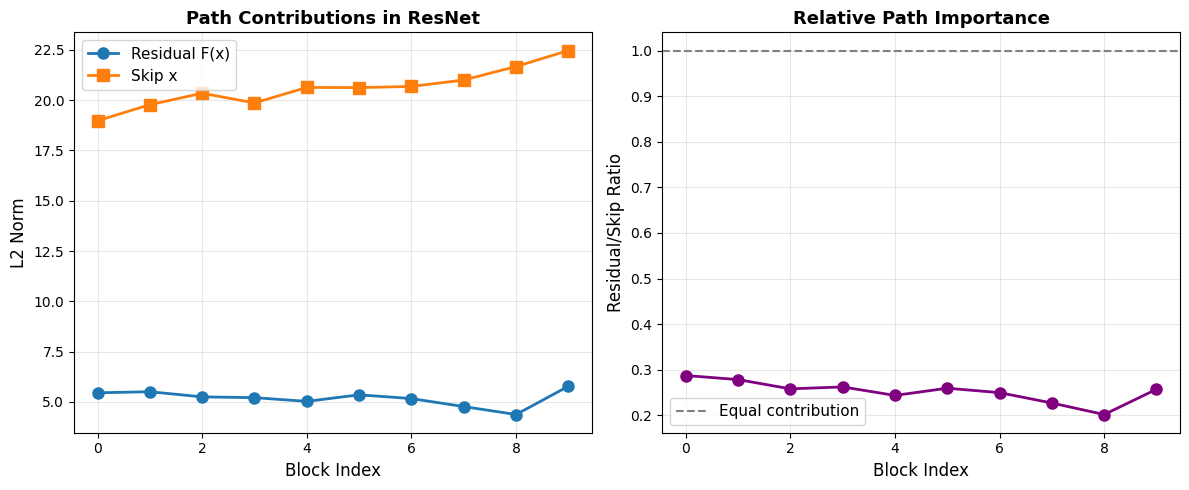

Average residual/skip ratio: 0.252

Interpretation:
  Skip connections dominate → network acts more like a shallow ensemble


In [9]:
def compute_path_contributions(model, x):
    """Compute contribution of each path through a ResNet.
    
    For each block, we measure:
    - Contribution of residual path F(x)
    - Contribution of skip connection x
    """
    model.eval()
    contributions = []
    
    # Project to hidden dimension
    x = F.relu(model.input_layer(x))
    
    # Pass through blocks and measure contributions
    with torch.no_grad():
        for block in model.blocks:
            identity = x
            
            # Residual path
            out = block.linear1(x)
            out = block.bn1(out)
            out = F.relu(out)
            out = block.linear2(out)
            out = block.bn2(out)
            
            # Measure magnitudes
            residual_norm = out.norm().item()
            skip_norm = identity.norm().item()
            
            contributions.append({
                'residual': residual_norm,
                'skip': skip_norm,
                'ratio': residual_norm / (skip_norm + 1e-8)
            })
            
            # Continue forward
            x = F.relu(out + identity)
    
    return contributions

# Measure contributions
x = torch.randn(32, 64, device=device)
contributions = compute_path_contributions(resnet, x)

# Plot
blocks = range(len(contributions))
residual_norms = [c['residual'] for c in contributions]
skip_norms = [c['skip'] for c in contributions]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(blocks, residual_norms, 'o-', label='Residual F(x)', linewidth=2, markersize=8)
plt.plot(blocks, skip_norms, 's-', label='Skip x', linewidth=2, markersize=8)
plt.xlabel('Block Index', fontsize=12)
plt.ylabel('L2 Norm', fontsize=12)
plt.title('Path Contributions in ResNet', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
ratios = [c['ratio'] for c in contributions]
plt.plot(blocks, ratios, 'o-', linewidth=2, markersize=8, color='purple')
plt.axhline(y=1, color='gray', linestyle='--', label='Equal contribution')
plt.xlabel('Block Index', fontsize=12)
plt.ylabel('Residual/Skip Ratio', fontsize=12)
plt.title('Relative Path Importance', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average residual/skip ratio: {np.mean(ratios):.3f}")
print(f"\nInterpretation:")
if np.mean(ratios) < 0.5:
    print("  Skip connections dominate → network acts more like a shallow ensemble")
elif np.mean(ratios) > 2.0:
    print("  Residual paths dominate → network acts more like a deep network")
else:
    print("  Balanced contributions → true ensemble behavior")

### Key Insight: Ensemble Diversity

The ratio of residual-to-skip contributions shows how the network balances between:
- **Shallow paths** (many skips) - process information quickly
- **Deep paths** (few skips) - process information with more transformations

This diversity is powerful - different paths specialize in different aspects of the task, similar to an ensemble of models. Research has shown that deleting individual layers from a trained ResNet has minimal impact, confirming the ensemble interpretation.

## 5. Training Comparison: Plain vs ResNet

### Training on a Real Task

Let's train both plain and residual networks on a real classification task to see the difference in practice.

In [10]:
def train_network(model, num_epochs=50, batch_size=128, lr=0.001):
    """Train a network on synthetic data."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    train_accs = []
    
    for epoch in range(num_epochs):
        epoch_losses = []
        epoch_correct = 0
        epoch_total = 0
        
        # Mini-batches
        for _ in range(10):  # 10 batches per epoch
            # Generate random data (10 classes)
            x = torch.randn(batch_size, 64, device=device)
            # Create somewhat structured targets (based on input)
            target = (x.sum(dim=1) > 0).long() * 5 + torch.randint(0, 5, (batch_size,), device=device)
            target = target % 10  # Keep in range [0, 9]
            
            # Forward pass
            output = model(x)
            loss = F.cross_entropy(output, target)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Track metrics
            epoch_losses.append(loss.item())
            pred = output.argmax(dim=1)
            epoch_correct += (pred == target).sum().item()
            epoch_total += batch_size
        
        # Epoch metrics
        train_losses.append(np.mean(epoch_losses))
        train_accs.append(100.0 * epoch_correct / epoch_total)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {train_losses[-1]:.4f} | Acc: {train_accs[-1]:.2f}%")
    
    return train_losses, train_accs

# Create fresh networks
print("Training Plain Network (20 layers)...")
plain_net_train = PlainDeepNetwork(input_size=64, hidden_size=64, num_layers=20, output_size=10).to(device)
plain_losses, plain_accs = train_network(plain_net_train, num_epochs=50, lr=0.001)

print("\nTraining ResNet (20 layers)...")
resnet_train = ResNet(input_size=64, hidden_size=64, num_blocks=10, output_size=10).to(device)
resnet_losses, resnet_accs = train_network(resnet_train, num_epochs=50, lr=0.001)

Training Plain Network (20 layers)...


Epoch  10 | Loss: 2.3030 | Acc: 9.30%


Epoch  20 | Loss: 2.3023 | Acc: 10.00%


Epoch  30 | Loss: 2.3035 | Acc: 9.84%


Epoch  40 | Loss: 2.3022 | Acc: 11.17%


...

Epoch  10 | Loss: 2.2222 | Acc: 15.62%


Epoch  20 | Loss: 1.9571 | Acc: 16.64%


Epoch  30 | Loss: 1.8545 | Acc: 19.06%


Epoch  40 | Loss: 1.8032 | Acc: 19.30%


Epoch  50 | Loss: 1.7876 | Acc: 19.61%


### Visualizing Training Dynamics

Let's plot the learning curves to see how the networks learn over time.

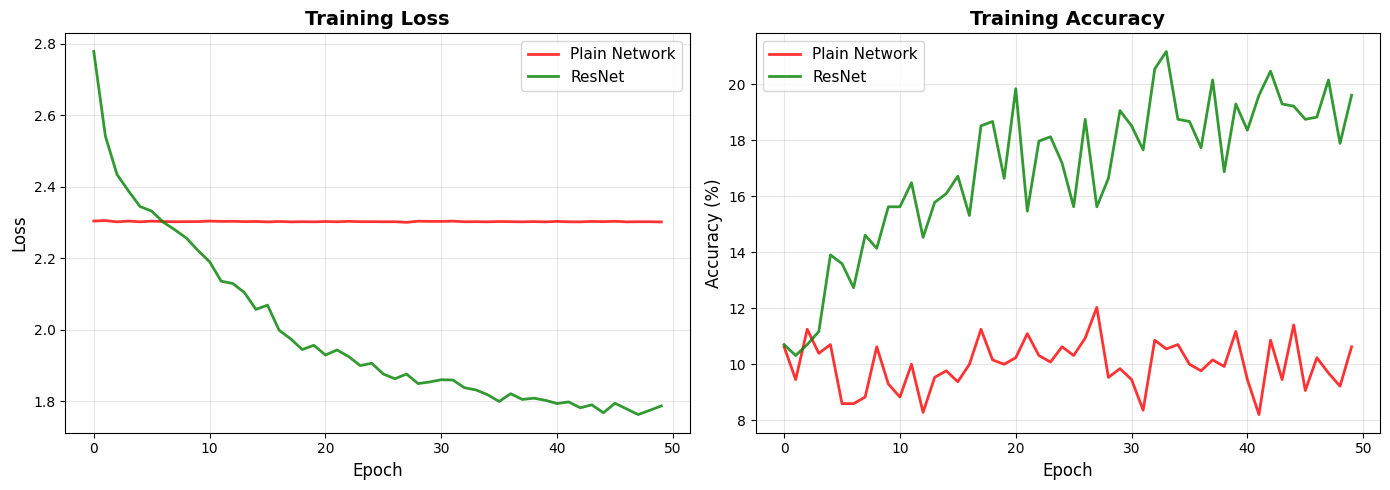


Final Results:
Plain Network - Loss: 2.3020, Acc: 10.62%
ResNet - Loss: 1.7876, Acc: 19.61%

ResNet improvement: 8.98 percentage points


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(plain_losses, label='Plain Network', linewidth=2, alpha=0.8, color='red')
ax1.plot(resnet_losses, label='ResNet', linewidth=2, alpha=0.8, color='green')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(plain_accs, label='Plain Network', linewidth=2, alpha=0.8, color='red')
ax2.plot(resnet_accs, label='ResNet', linewidth=2, alpha=0.8, color='green')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Plain Network - Loss: {plain_losses[-1]:.4f}, Acc: {plain_accs[-1]:.2f}%")
print(f"ResNet - Loss: {resnet_losses[-1]:.4f}, Acc: {resnet_accs[-1]:.2f}%")
print(f"\nResNet improvement: {resnet_accs[-1] - plain_accs[-1]:.2f} percentage points")

### Key Observation: Better Optimization

Notice that ResNet typically:
1. **Converges faster** - reaches low loss in fewer epochs
2. **Achieves better final performance** - lower loss, higher accuracy
3. **More stable training** - smoother learning curves

These benefits become even more pronounced as networks get deeper. In the famous ResNet paper, plain networks with 56 layers performed **worse** than 20-layer networks, while ResNets continued to improve up to 152 layers!

## 6. The Depth Experiment

### Does Deeper Always Mean Better?

Let's empirically test the famous result from the ResNet paper: plain networks degrade with depth, but ResNets improve.

In [12]:
def quick_train(model, num_steps=500, batch_size=128, lr=0.001):
    """Quick training for comparison."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    final_losses = []
    
    for step in range(num_steps):
        x = torch.randn(batch_size, 64, device=device)
        target = (x.sum(dim=1) > 0).long() * 5 + torch.randint(0, 5, (batch_size,), device=device)
        target = target % 10
        
        output = model(x)
        loss = F.cross_entropy(output, target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if step >= num_steps - 50:  # Average last 50 steps
            final_losses.append(loss.item())
    
    return np.mean(final_losses)

# Test different depths
depths = [2, 4, 6, 8, 10, 15, 20]
plain_results = []
resnet_results = []

print("Testing different network depths...\n")
for depth in depths:
    print(f"Depth {depth}:", end=' ')
    
    # Plain network
    plain = PlainDeepNetwork(64, 64, depth, 10).to(device)
    plain_loss = quick_train(plain, num_steps=500)
    plain_results.append(plain_loss)
    print(f"Plain={plain_loss:.4f}", end=', ')
    
    # ResNet (depth/2 blocks since each block has 2 layers)
    resnet_depth = max(1, depth // 2)
    resnet = ResNet(64, 64, resnet_depth, 10).to(device)
    resnet_loss = quick_train(resnet, num_steps=500)
    resnet_results.append(resnet_loss)
    print(f"ResNet={resnet_loss:.4f}")

print("\nDone!")

Testing different network depths...

Depth 2: 

Plain=1.7081, 

ResNet=1.7021
Depth 4: 

Plain=1.6723, 

ResNet=1.7116
Depth 6: 

...

ResNet=1.7500
Depth 15: 

Plain=1.6805, 

ResNet=1.7563
Depth 20: 

Plain=2.3026, 

ResNet=1.7929

Done!


### Visualizing the Depth Paradox

Let's plot how performance changes with depth for both architectures.

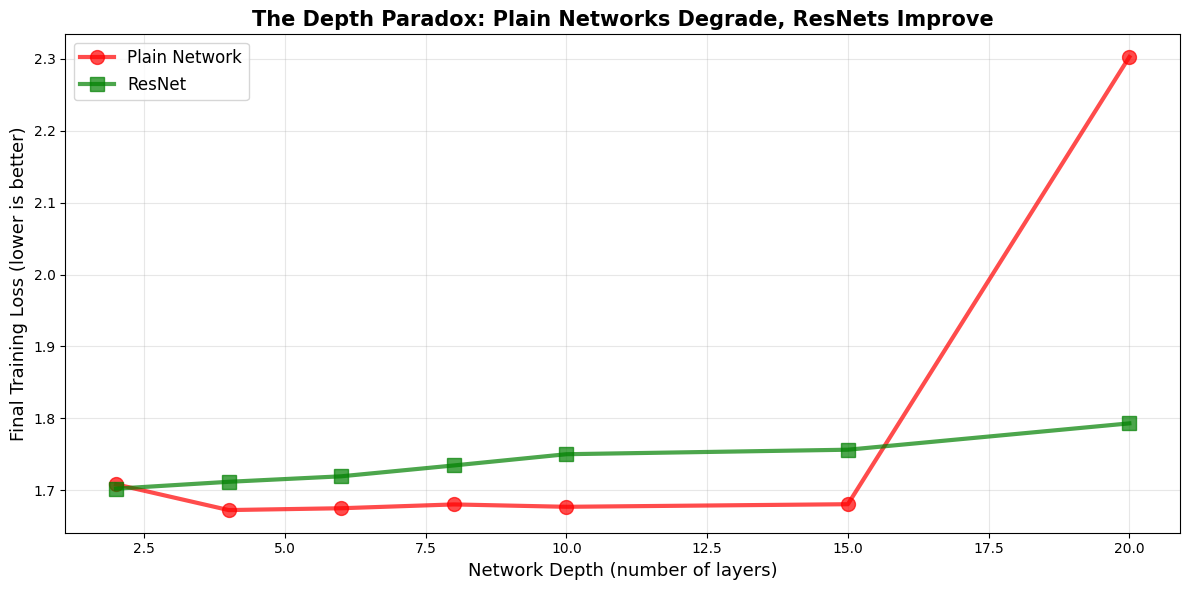


Key Observations:
1. Plain network: Loss increases from 1.7081 (depth 2) to 2.3026 (depth 20)
2. ResNet: Loss decreases from 1.7021 (depth 2) to 1.7929 (depth 20)
3. At depth 20, ResNet is 1.28x better than plain network!


In [13]:
plt.figure(figsize=(12, 6))
plt.plot(depths, plain_results, 'o-', linewidth=3, markersize=10, label='Plain Network', color='red', alpha=0.7)
plt.plot(depths, resnet_results, 's-', linewidth=3, markersize=10, label='ResNet', color='green', alpha=0.7)
plt.xlabel('Network Depth (number of layers)', fontsize=13)
plt.ylabel('Final Training Loss (lower is better)', fontsize=13)
plt.title('The Depth Paradox: Plain Networks Degrade, ResNets Improve', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey Observations:")
print(f"1. Plain network: Loss increases from {plain_results[0]:.4f} (depth {depths[0]}) to {plain_results[-1]:.4f} (depth {depths[-1]})")
print(f"2. ResNet: Loss decreases from {resnet_results[0]:.4f} (depth {depths[0]}) to {resnet_results[-1]:.4f} (depth {depths[-1]})")
print(f"3. At depth {depths[-1]}, ResNet is {plain_results[-1]/resnet_results[-1]:.2f}x better than plain network!")

### The Famous ResNet Result

This reproduces the key finding from the ResNet paper:

**Plain networks:** Performance **degrades** as depth increases (not due to overfitting, but optimization difficulty)

**ResNets:** Performance **improves** with depth, enabling networks with 100+ layers

This was revolutionary - it showed that the depth bottleneck wasn't fundamental to neural networks, but rather a consequence of poor gradient flow that skip connections elegantly solve.

## 7. Residual Connection Variants

### Pre-Activation Residual Block

The original ResNet used **post-activation** (activate after adding skip connection). Research found **pre-activation** works even better.

In [14]:
class PreActivationResidualBlock(nn.Module):
    """Pre-activation residual block (improved design).
    
    Key difference: BatchNorm and ReLU BEFORE convolutions.
    This creates a cleaner gradient path through skip connections.
    """
    
    def __init__(self, hidden_size):
        super().__init__()
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.linear1 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        
    def forward(self, x):
        identity = x
        
        # Pre-activation: BN and ReLU BEFORE linear
        out = F.relu(self.bn1(x))
        out = self.linear1(out)
        out = F.relu(self.bn2(out))
        out = self.linear2(out)
        
        # Skip connection (no activation after)
        out = out + identity
        
        return out  # No ReLU here!

# Compare structures
print("Post-activation (original ResNet):")
print("  x → Linear → BN → ReLU → Linear → BN → (+skip) → ReLU → output")
print()
print("Pre-activation (improved):")
print("  x → BN → ReLU → Linear → BN → ReLU → Linear → (+skip) → output")
print()
print("Key advantage: Skip connection has no activations in its path,")
print("               creating a completely clean gradient highway!")

Post-activation (original ResNet):
  x → Linear → BN → ReLU → Linear → BN → (+skip) → ReLU → output

Pre-activation (improved):
  x → BN → ReLU → Linear → BN → ReLU → Linear → (+skip) → output

Key advantage: Skip connection has no activations in its path,
               creating a completely clean gradient highway!


### Bottleneck Residual Block

For deeper networks (ResNet-50+), use **bottleneck blocks** that reduce parameters via 1×1 convolutions.

In [15]:
class BottleneckBlock(nn.Module):
    """Bottleneck residual block for deeper networks.
    
    Structure: 1x1 (reduce) → 3x3 (transform) → 1x1 (expand)
    Reduces computation by 4x compared to regular residual block.
    """
    
    def __init__(self, hidden_size, bottleneck_size=None):
        super().__init__()
        if bottleneck_size is None:
            bottleneck_size = hidden_size // 4  # Typical: reduce to 1/4
        
        # 1x1: Reduce dimensions
        self.linear1 = nn.Linear(hidden_size, bottleneck_size)
        self.bn1 = nn.BatchNorm1d(bottleneck_size)
        
        # 3x3: Transform (simulated with linear for simplicity)
        self.linear2 = nn.Linear(bottleneck_size, bottleneck_size)
        self.bn2 = nn.BatchNorm1d(bottleneck_size)
        
        # 1x1: Expand back
        self.linear3 = nn.Linear(bottleneck_size, hidden_size)
        self.bn3 = nn.BatchNorm1d(hidden_size)
        
    def forward(self, x):
        identity = x
        
        # Bottleneck path
        out = F.relu(self.bn1(self.linear1(x)))  # Reduce
        out = F.relu(self.bn2(self.linear2(out)))  # Transform
        out = self.bn3(self.linear3(out))  # Expand
        
        # Skip connection
        out = F.relu(out + identity)
        
        return out

# Compare parameter counts
hidden_size = 256
regular_block = ResidualBlock(hidden_size)
bottleneck_block = BottleneckBlock(hidden_size)

regular_params = sum(p.numel() for p in regular_block.parameters())
bottleneck_params = sum(p.numel() for p in bottleneck_block.parameters())

print(f"Hidden size: {hidden_size}")
print(f"\nRegular Block: {regular_params:,} parameters")
print(f"Bottleneck Block: {bottleneck_params:,} parameters")
print(f"\nParameter reduction: {regular_params/bottleneck_params:.2f}x fewer!")
print(f"\nThis enables much deeper networks (ResNet-50, ResNet-101, ResNet-152)")

Hidden size: 256

Regular Block: 132,608 parameters
Bottleneck Block: 38,016 parameters

Parameter reduction: 3.49x fewer!

This enables much deeper networks (ResNet-50, ResNet-101, ResNet-152)


## 8. Applications Beyond ResNet

### Transformers

Residual connections are **essential** in Transformers around both attention and feedforward layers:

```python
# Attention block with residual
x = x + attention(x)

# Feedforward block with residual  
x = x + feedforward(x)
```

This enables Transformers with 100+ layers (GPT-3 has 96 layers).

### Dense Connections (DenseNet)

**DenseNet** takes skip connections further - each layer connects to **all previous layers**:

```python
x1 = layer1(x0)
x2 = layer2(concat([x0, x1]))  # Connect to all previous
x3 = layer3(concat([x0, x1, x2]))  # Connect to all previous
```

This creates even stronger gradient flow but uses more memory.

### U-Net (Image Segmentation)

**U-Net** uses skip connections between encoder and decoder to preserve spatial information:

```
Encoder          Decoder
x1 → down1 ────→ concat → up1
      ↓                    ↑
     down2 ──────→ concat → up2
```

Critical for pixel-wise tasks like segmentation and denoising.

## Key Takeaways

### Core Concepts

1. **Vanishing gradients** plague deep plain networks - gradients shrink exponentially through many layers

2. **Skip connections** solve this by creating gradient highways: $H(x) = F(x) + x$

3. **ResNets** enable training 100+ layer networks where plain networks fail at 20+ layers

### Why They Work

1. **Easier optimization**: Learning residual $F(x) = H(x) - x$ is easier than learning $H(x)$ directly

2. **Gradient highways**: The derivative $\frac{\partial}{\partial x}(F(x) + x) = \frac{\partial F(x)}{\partial x} + 1$ ensures gradients never vanish (the $+1$ term)

3. **Implicit ensemble**: ResNets with $n$ blocks create $2^n$ paths, acting like an ensemble of networks with shared weights

### Design Patterns

1. **Basic block**: Two layers with skip connection, used in ResNet-18/34

2. **Bottleneck block**: 1×1 reduce → 3×3 transform → 1×1 expand, used in ResNet-50/101/152

3. **Pre-activation**: Batch norm and activation before convolutions creates cleaner gradient flow

### Impact

Residual connections revolutionized deep learning:
- **Computer Vision**: ResNet, EfficientNet, Vision Transformers
- **NLP**: Transformers (GPT, BERT), all use residual connections
- **General principle**: Now standard in almost all deep architectures

The 2015 ResNet paper is one of the most influential in deep learning history, enabling the "deep" in modern deep learning.

## References

**Papers:**
- [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) (He et al., 2015) - The original ResNet paper
- [Identity Mappings in Deep Residual Networks](https://arxiv.org/abs/1603.05027) (He et al., 2016) - Pre-activation ResNet
- [Residual Networks Behave Like Ensembles](https://arxiv.org/abs/1605.06431) (Veit et al., 2016) - Ensemble interpretation

**Resources:**
- [Visualizing ResNets](https://tensorspace.org/html/playground/resnet50.html) - Interactive visualization
- [ResNet Explained](https://towardsdatascience.com/understanding-and-visualizing-resnets-442284831be8) - Detailed tutorial